In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Time series decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# ARIMA model for forecasting
from statsmodels.tsa.arima.model import ARIMA

# Model evaluation
from sklearn.metrics import mean_squared_error


In [4]:
# Load dataset and parse Month column as datetime
df = pd.read_csv(
    "airline-passengers.csv",
    parse_dates=["Month"],
    index_col="Month"
)

# Display first few rows
df.head()


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [5]:
# Check structure
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


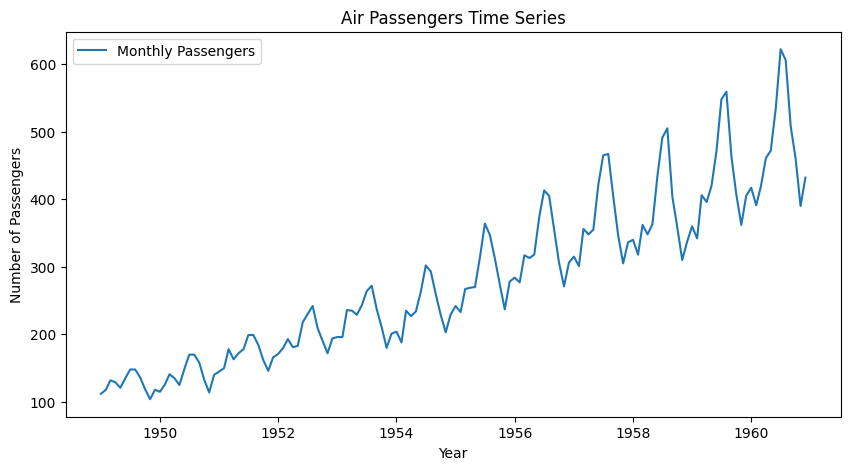

In [6]:
plt.figure(figsize=(10,5))
plt.plot(df["Passengers"], label="Monthly Passengers")
plt.title("Air Passengers Time Series")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()


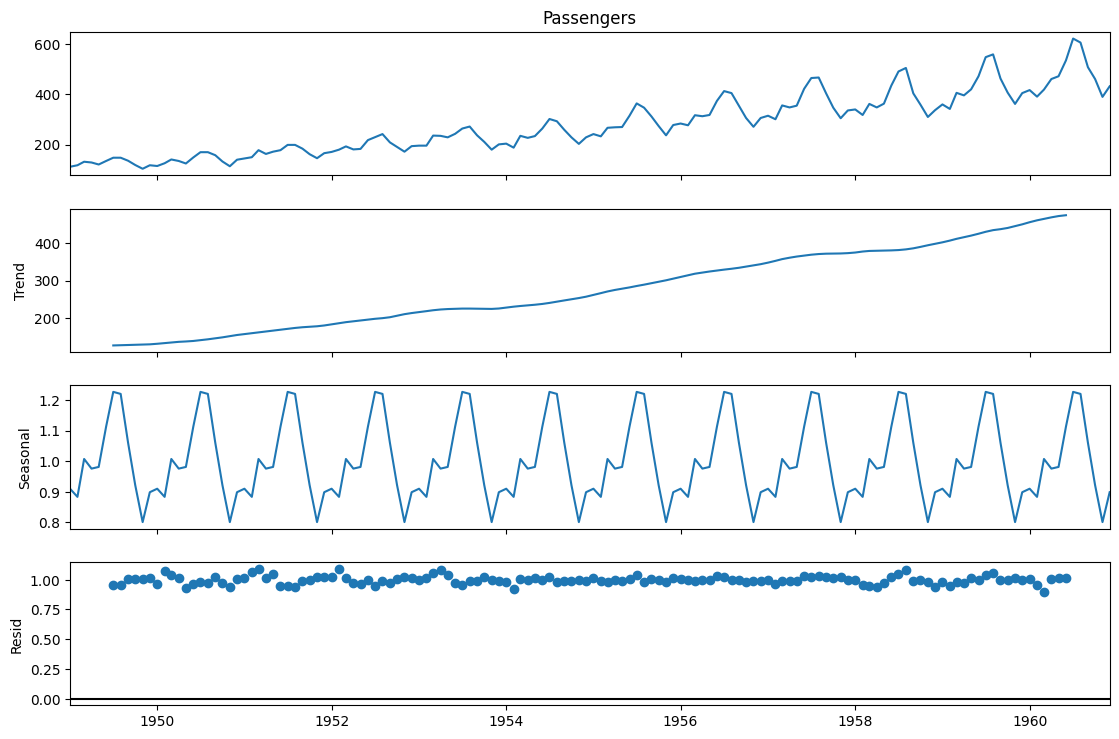

In [7]:
# Decompose time series into components
decomposition = seasonal_decompose(
    df["Passengers"],
    model="multiplicative"
)

# Plot decomposition
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()


Insights:

Trend shows long-term growth

Seasonality repeats yearly

Residual captures noise

In [8]:
# 6-month moving average
df["MA_6"] = df["Passengers"].rolling(window=6).mean()

# 12-month moving average
df["MA_12"] = df["Passengers"].rolling(window=12).mean()


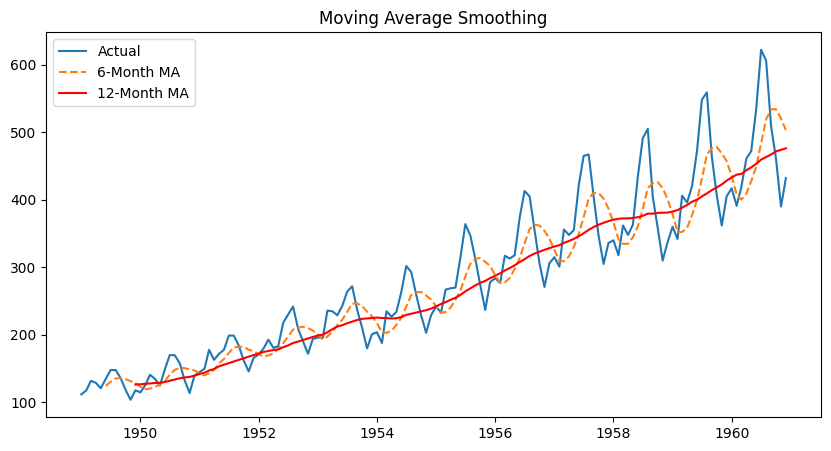

In [9]:
# Plot moving averages
plt.figure(figsize=(10,5))
plt.plot(df["Passengers"], label="Actual")
plt.plot(df["MA_6"], label="6-Month MA", linestyle="--")
plt.plot(df["MA_12"], label="12-Month MA", color="red")
plt.title("Moving Average Smoothing")
plt.legend()
plt.show()


Interpretation:

MA-12 removes seasonality better

MA-6 reacts faster to changes

In [10]:
# Split data: last 12 months for testing
train = df.iloc[:-12]
test = df.iloc[-12:]


In [11]:
# Build ARIMA model
model = ARIMA(
    train["Passengers"],
    order=(2,1,1),
    seasonal_order=(1,1,1,12)
)

# Fit model
result = model.fit()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Us

In [12]:
# Forecast next 12 months
forecast = result.forecast(steps=12)


In [13]:
rmse = np.sqrt(mean_squared_error(test["Passengers"], forecast))
print(f"RMSE: {rmse:.2f}")


RMSE: 21.17


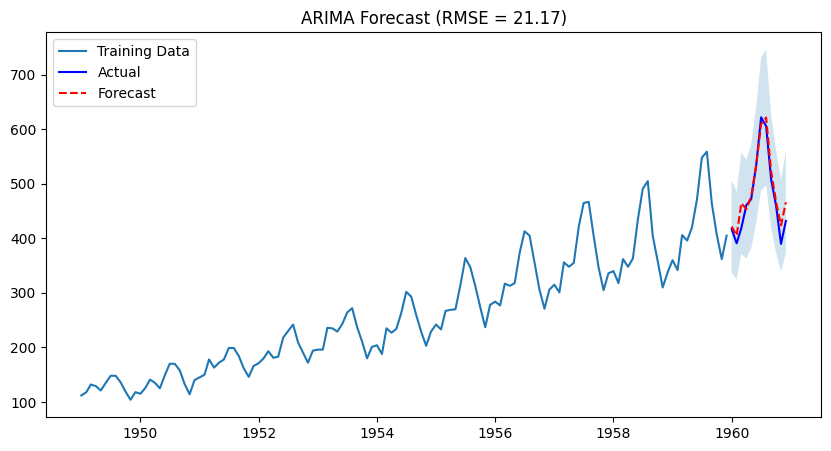

In [14]:
plt.figure(figsize=(10,5))
plt.plot(train.index, train["Passengers"], label="Training Data")
plt.plot(test.index, test["Passengers"], label="Actual", color="blue")
plt.plot(test.index, forecast, label="Forecast", color="red", linestyle="--")

# Confidence band (approx)
plt.fill_between(
    test.index,
    forecast * 0.8,
    forecast * 1.2,
    alpha=0.2
)

plt.title(f"ARIMA Forecast (RMSE = {rmse:.2f})")
plt.legend()
plt.show()


INSIGHTS:
1. Passenger traffic increased consistently over years.
2. Strong yearly seasonality with peaks in mid-year.
3. 12-month moving average best captures trend.
4. ARIMA model successfully captures trend and seasonality.
5. Forecast suggests continued passenger growth.
